# DGNet — SHREC16 Original

**Tâche** : classification de formes 3D sur le dataset SHREC16 (30 classes), avec l'architecture DGNet (Jittor).

**Pipeline** :
1. Clonage du projet et validation
2. Environnement Python isolé pour Jittor (avec correctifs CUDA/cuDNN)
3. Connexion et prétraitement du dataset (600 maillages)
4. Entraînement du modèle de classification (200 epochs)
5. Évaluation complète (accuracy, precision, recall, F1-score — macro et weighted)
6. Rapport final exporté en Markdown


In [1]:
from pathlib import Path

WORKING_ROOT = Path("/kaggle/working")
PROJECT_NAME = "3d-mesh-augmentation-study"
PROJECT_ROOT = WORKING_ROOT / PROJECT_NAME

GITHUB_URL = "https://github.com/Bilal51002/3d-mesh-augmentation-study.git"
GITHUB_BRANCH = "feat/dgnet-modelnet10-preprocessing"

PYRAMID_LEVELS = 6

print("Project root :", PROJECT_ROOT)

Project root : /kaggle/working/3d-mesh-augmentation-study


## 1. Clonage du projet

Récupération du dépôt GitHub contenant le pipeline DGNet et ses adaptateurs.

In [2]:
import os
import shutil
import subprocess

# Se replacer dans /kaggle/working AVANT toute suppression, pour ne jamais
# supprimer le repertoire dans lequel le kernel est physiquement positionne
# (sinon subprocess.run echoue avec "Unable to read current working directory").
os.chdir(WORKING_ROOT)

if PROJECT_ROOT.exists():
    shutil.rmtree(PROJECT_ROOT)

subprocess.run(
    [
        "git", "clone", "--recurse-submodules",
        "--branch", GITHUB_BRANCH,
        GITHUB_URL, str(PROJECT_ROOT),
    ],
    cwd=str(WORKING_ROOT),
    check=True,
)

print("✅ Projet cloné :", PROJECT_ROOT)


Cloning into '/kaggle/working/3d-mesh-augmentation-study'...
Submodule 'models/dgnet' (https://github.com/li-xl/DGNet.git) registered for path 'models/dgnet'
Cloning into '/kaggle/working/3d-mesh-augmentation-study/models/dgnet'...


Submodule path 'models/dgnet': checked out '70abf402b58f7d44f0765c0436bfb03b53af4a5d'
✅ Projet cloné : /kaggle/working/3d-mesh-augmentation-study


In [3]:
%cd /kaggle/working/3d-mesh-augmentation-study


/kaggle/working/3d-mesh-augmentation-study


In [4]:
!git branch --show-current
!git log -1 --oneline
!git submodule status


feat/dgnet-modelnet10-preprocessing
cf3dc4f (HEAD -> feat/dgnet-modelnet10-preprocessing, origin/feat/dgnet-modelnet10-preprocessing) Kaggle Notebook | 01-dgnet-modelnet10-setup-preprocessing-fusionne | Version 2
 70abf402b58f7d44f0765c0436bfb03b53af4a5d models/dgnet (heads/master)


## 2. Validation du projet

Vérifie que tous les fichiers nécessaires (adaptateurs, sous-module DGNet) sont bien présents après le clonage.

In [5]:
required_files = [
    PROJECT_ROOT / "adapters/dgnet/face_pool_compat.py",
    PROJECT_ROOT / "models/dgnet/jmesh/layers/face_pool.py",
]

missing_files = [p for p in required_files if not p.is_file()]

for path in required_files:
    status = "OK" if path.is_file() else "MANQUANT"
    print(f"{status:8} {path.relative_to(PROJECT_ROOT)}")

if missing_files:
    raise FileNotFoundError(f"Fichiers manquants : {missing_files}")

print("\n✅ Le code DGNet est complet.")

OK       adapters/dgnet/face_pool_compat.py
OK       models/dgnet/jmesh/layers/face_pool.py

✅ Le code DGNet est complet.


## 3. Environnement Python isolé pour Jittor

Jittor nécessite Python 3.10 et des dépendances CUDA/cuDNN spécifiques, incompatibles avec le Python 3.12 du kernel Kaggle. On crée donc un venv dédié, avec les correctifs nécessaires pour éviter les téléchargements automatiques cassés de Jittor (CUDA, MKL, cutlass, cuDNN).

### Nettoyage (à exécuter avant chaque reconstruction du venv)


In [6]:
import shutil
from pathlib import Path

shutil.rmtree(WORKING_ROOT / "dgnet-jittor-env", ignore_errors=True)
shutil.rmtree(Path("/root/.cache/jittor"), ignore_errors=True)
print("Nettoyage terminé.")


Nettoyage terminé.


In [7]:
import sys

VENV_ROOT = WORKING_ROOT / "dgnet-jittor-env"
VENV_PYTHON = VENV_ROOT / "bin" / "python"
READY_MARKER = VENV_ROOT / ".dgnet_environment_ready"

REQUIRED_PACKAGES = [
    "numpy==1.26.4",
    "trimesh==4.12.2",
    "fast-simplification==0.1.13",
    "jittor==1.3.11.0",
    "tensorboardX==2.6.4",
    "plyfile",
    "pyyaml",
    "tqdm",
    "scipy",
    "pandas",
    "scikit-learn",
    "matplotlib",
    "psutil",
    "networkx",
    "open3d",
    "wrapt",
]

os.chdir(WORKING_ROOT)

# Jittor 1.3.11.0 crashes on Python >= 3.11 (confirmed in its source code:
# py_var_tracer.cc checks PY_MINOR_VERSION>=11 and aborts). Use Python 3.10
# for the isolated venv instead of the main kernel's Python 3.12.
python310_path = shutil.which("python3.10")
if python310_path is None:
    print("Python 3.10 introuvable, installation via apt...")
    subprocess.run(["apt-get", "update", "-qq"], check=True)
    subprocess.run(
        ["apt-get", "install", "-y", "-qq", "python3.10", "python3.10-venv", "python3.10-distutils", "python3.10-dev"],
        check=True,
    )
    python310_path = shutil.which("python3.10")

if python310_path is None:
    raise RuntimeError("Impossible d'installer Python 3.10.")

print("Python 3.10 trouve :", python310_path)

environment_ready = VENV_PYTHON.is_file() and READY_MARKER.is_file()

if not environment_ready:
    if VENV_ROOT.exists():
        shutil.rmtree(VENV_ROOT)

    print("1. Installation de virtualenv...")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", "--upgrade", "virtualenv"],
        cwd=WORKING_ROOT, check=True,
    )

    print("2. Création de l'environnement isolé (Python 3.10)...")
    subprocess.run(
        [sys.executable, "-m", "virtualenv", "--clear", "--python", python310_path, str(VENV_ROOT)],
        cwd=WORKING_ROOT, check=True,
    )

    if not VENV_PYTHON.is_file():
        raise FileNotFoundError(f"Python isolé introuvable : {VENV_PYTHON}")

    print("3. Installation des dépendances DGNet...")
    subprocess.run(
        [str(VENV_PYTHON), "-m", "pip", "install", "--quiet", "--no-cache-dir",
         "--upgrade", "pip", "setuptools", "wheel"],
        cwd=WORKING_ROOT, check=True,
    )
    subprocess.run(
        [str(VENV_PYTHON), "-m", "pip", "install", "--quiet", "--no-cache-dir", *REQUIRED_PACKAGES],
        cwd=WORKING_ROOT, check=True,
    )

    READY_MARKER.write_text("DGNet environment ready.\n", encoding="utf-8")
else:
    print("L'environnement isolé existe déjà. Installation ignorée.")

if not VENV_PYTHON.is_file():
    raise FileNotFoundError(f"Interpréteur introuvable : {VENV_PYTHON}")

print("\n✅ Environnement isolé prêt (Python 3.10)")
print("Python :", VENV_PYTHON)

Python 3.10 trouve : /usr/bin/python3.10
1. Installation de virtualenv...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 96.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.6/470.6 kB 22.7 MB/s eta 0:00:00
2. Création de l'environnement isolé (Python 3.10)...
created virtual environment CPython3.10.12.final.0-64-x86_64 in 970ms
  creator CPython3Posix(dest=/kaggle/working/dgnet-jittor-env, clear=True, no_vcs_ignore=False, global=False)
  seeder FromAppData(download=False, pip=bundle, setuptools=bundle, via=copy, app_data_dir=/root/.cache/virtualenv)
    added seed packages: pip==26.2.1, setuptools==84.0.0
  activators BashActivator,CShellActivator,FishActivator,NushellActivator,PowerShellActivator,PythonActivator,XonshActivator
3. Installation des dépendances DGNet...

✅ Environnement isolé prêt (Python 3.10)
Python : /kaggle/working/dgnet-jittor-env/bin/python


In [8]:
import os

real_path = "/usr/bin/x86_64-linux-gnu-python3.10-config"
link_path = "/usr/bin/python3.10-config"

if not os.path.exists(link_path):
    os.symlink(real_path, link_path)
    print("Raccourci créé :", link_path, "->", real_path)
else:
    print("Déjà présent :", link_path)

check = subprocess.run([link_path, "--includes"], capture_output=True, text=True)
print("Test :", check.stdout, check.stderr)

Raccourci créé : /usr/bin/python3.10-config -> /usr/bin/x86_64-linux-gnu-python3.10-config
Test : -I/usr/include/python3.10 -I/usr/include/python3.10
 


In [9]:
completed = subprocess.run(
    [str(VENV_PYTHON), "-c", "import site; print(site.getsitepackages()[0])"],
    capture_output=True, text=True, check=True,
)
VENV_SITE_PACKAGES = completed.stdout.strip()

VENV_ENV = os.environ.copy()
VENV_ENV["PYTHONPATH"] = VENV_SITE_PACKAGES
VENV_ENV.pop("PYTHONSTARTUP", None)

# FIX: utiliser le nvcc DEJA installé sur le système Kaggle, pour que Jittor
# n'essaie jamais de télécharger sa propre copie CUDA (serveur cg.cs.tsinghua.edu.cn cassé).
# IMPORTANT: verifiez le vrai chemin sur CETTE session via
# find / -iname nvcc -type f 2>/dev/null -- remplacez ci-dessous si different.
VENV_ENV["nvcc_path"] = "/usr/local/cuda/bin/nvcc"

# FIX: éviter les téléchargements MKL/oneDNN et cutlass (même cause réseau que CUDA).
VENV_ENV["use_mkl"] = "0"
VENV_ENV["use_cutlass"] = "0"


def run_in_venv(args, **kwargs):
    full_args = [str(VENV_PYTHON), "-S"] + list(args)
    kwargs.setdefault("env", VENV_ENV)
    kwargs.setdefault("cwd", WORKING_ROOT)
    return subprocess.run(full_args, **kwargs)


check = run_in_venv(["-c", "import trimesh, jittor; print('OK', trimesh.__version__)"],
                     capture_output=True, text=True)
print("STDOUT:", check.stdout)
print("STDERR:", check.stderr[-1500:] if check.stderr else "")


STDOUT: [i 0915 11:17:49.462974 72 lock.py:85] Create lock file:/root/.cache/jittor/jt1.3.11/g++11.4.0/py3.10.12/Linux-6.12.90+xce/IntelRXeonRCPUx5a/9ee7/jittor.lock
[i 0915 11:17:49.476071 72 compiler.py:955] Jittor(1.3.11.0) src: /kaggle/working/dgnet-jittor-env/lib/python3.10/site-packages/jittor
[i 0915 11:17:49.479537 72 compiler.py:956] g++ at /usr/bin/g++(11.4.0)
[i 0915 11:17:49.479596 72 compiler.py:957] cache_path: /root/.cache/jittor/jt1.3.11/g++11.4.0/py3.10.12/Linux-6.12.90+xce/IntelRXeonRCPUx5a/9ee7/default
[i 0915 11:17:49.493986 72 compiler.py:900] Found nvcc(12.8.93) at /usr/local/cuda/bin/nvcc
[i 0915 11:17:49.502601 72 __init__.py:412] Found addr2line(2.38) at /usr/bin/addr2line.
[i 0915 11:17:49.974495 72 compiler.py:1012] cuda key:cu12.8.93_sm_75
[i 0915 11:17:50.010092 72 compiler.py:33] Create cache dir: /root/.cache/jittor/jt1.3.11/g++11.4.0/py3.10.12/Linux-6.12.90+xce/IntelRXeonRCPUx5a/9ee7/default/cu12.8.93_sm_75
[i 0915 11:17:50.010296 72 compiler.py:33] Crea

In [10]:
import importlib
import platform

modules_to_check = {
    "NumPy": "numpy", "SciPy": "scipy", "Pandas": "pandas",
    "Scikit-learn": "sklearn", "Trimesh": "trimesh",
    "TensorBoardX": "tensorboardX", "Jittor": "jittor",
    "Plyfile": "plyfile", "PyYAML": "yaml", "TQDM": "tqdm",
}

print("Environnement Python (noyau principal)")
print("Python   :", sys.version)
print("Platform :", platform.platform())
print()
for display_name, import_name in modules_to_check.items():
    try:
        module = importlib.import_module(import_name)
        version = getattr(module, "__version__", "version non exposée")
        print(f"{display_name:<16} ✅ {version}")
    except Exception as error:
        print(f"{display_name:<16} ❌ {type(error).__name__}: {error}")


Environnement Python (noyau principal)
Python   : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform : Linux-6.12.90+-x86_64-with-glibc2.35

NumPy            ✅ 2.0.2
SciPy            ✅ 1.16.3
Pandas           ✅ 2.3.3
Scikit-learn     ✅ 1.6.1
Trimesh          ❌ ModuleNotFoundError: No module named 'trimesh'
TensorBoardX     ❌ ModuleNotFoundError: No module named 'tensorboardX'
Jittor           ❌ ModuleNotFoundError: No module named 'jittor'
Plyfile          ❌ ModuleNotFoundError: No module named 'plyfile'
PyYAML           ✅ 6.0.3
TQDM             ✅ 4.67.3


In [11]:
completed = subprocess.run(
    [str(VENV_PYTHON), "-c", "import site; print(site.getsitepackages()[0])"],
    capture_output=True, text=True, check=True,
)
VENV_SITE_PACKAGES = completed.stdout.strip()

VENV_ENV = os.environ.copy()
VENV_ENV["PYTHONPATH"] = VENV_SITE_PACKAGES
VENV_ENV.pop("PYTHONSTARTUP", None)


def run_in_venv(args, **kwargs):
    """Lance VENV_PYTHON avec -S (ignore site/sitecustomize) et un
    PYTHONPATH explicite vers le site-packages du venv, pour eviter que
    le sitecustomize.py bruyant de Kaggle ne corrompe le cache Jittor."""
    full_args = [str(VENV_PYTHON), "-S"] + list(args)
    kwargs.setdefault("env", VENV_ENV)
    kwargs.setdefault("cwd", WORKING_ROOT)
    return subprocess.run(full_args, **kwargs)


# Verification
check = run_in_venv(["-c", "import trimesh, jittor; print('OK', trimesh.__version__)"],
                     capture_output=True, text=True)
print("STDOUT:", check.stdout)
print("STDERR:", check.stderr[-1000:] if check.stderr else "")

STDOUT: Downloading https://cg.cs.tsinghua.edu.cn/jittor/assets/cutlass.zip to /root/.cache/jittor/cutlass/cutlass.zip
Use time: 20.51 ms per iteration.
Example passed on CPU.
Compiling gen_ops_mkl_matmul_mkl_conv_mkl_test_mkl_conv_back___hash1b51ee(1/7) used: 2.010s eta: 12.062s
Compiling gen_ops_mkl_matmul_mkl_conv_mkl_test_mkl_conv_back___hash1b51ee(2/7) used: 3.266s eta: 8.165s
Compiling gen_ops_mkl_matmul_mkl_conv_mkl_test_mkl_conv_back___hash1b51ee(3/7) used: 3.284s eta: 4.378s
Compiling gen_ops_mkl_matmul_mkl_conv_mkl_test_mkl_conv_back___hash1b51ee(4/7) used: 3.340s eta: 2.505s
Compiling gen_ops_mkl_matmul_mkl_conv_mkl_test_mkl_conv_back___hash1b51ee(5/7) used: 3.487s eta: 1.395s
Compiling gen_ops_mkl_matmul_mkl_conv_mkl_test_mkl_conv_back___hash1b51ee(6/7) used: 5.080s eta: 0.847s
Compiling gen_ops_mkl_matmul_mkl_conv_mkl_test_mkl_conv_back___hash1b51ee(7/7) used: 5.668s eta: 0.000s

STDERR: ttor-env/lib/python3.10/site-packages/jittor/compile_extern.py", line 747, in <module>

In [12]:
import subprocess
from pathlib import Path

# 1. Installer cuDNN 8 ET cuBLAS 11 (dependance interne reelle de cuDNN 8.9.6 -
#    pas un conflit, le linker dynamique en a besoin comme fichier .so).
subprocess.run(
    [str(VENV_PYTHON), "-m", "pip", "install", "--quiet", "--no-deps",
     "nvidia-cudnn-cu11==8.9.6.50", "nvidia-cublas-cu11"],
    check=True,
)

nvidia_root = VENV_ROOT / "lib/python3.10/site-packages/nvidia"
cudnn_lib_dir = nvidia_root / "cudnn" / "lib"
cudnn_include_dir = nvidia_root / "cudnn" / "include"
cublas_lib_dir = nvidia_root / "cublas" / "lib"
assert cudnn_lib_dir.is_dir() and cublas_lib_dir.is_dir(), "Paquets NVIDIA introuvables."

cuda_lib_dir = Path("/usr/local/cuda/lib64")
cuda_include_dir = Path("/usr/local/cuda/include")
cuda_lib_dir.mkdir(parents=True, exist_ok=True)
cuda_include_dir.mkdir(parents=True, exist_ok=True)

def link(src, dst):
    if dst.exists() or dst.is_symlink():
        dst.unlink()
    dst.symlink_to(src)

created_libs, created_headers = [], []

for so_file in cudnn_lib_dir.glob("*.so*"):
    link(so_file, cuda_lib_dir / so_file.name)
    created_libs.append(so_file.name)
    if so_file.name.endswith(".so.8"):
        link(so_file, cuda_lib_dir / so_file.name[:-2])
        created_libs.append(so_file.name[:-2])

for so_file in cublas_lib_dir.glob("*.so*"):
    link(so_file, cuda_lib_dir / so_file.name)
    created_libs.append(so_file.name)

for h_file in cudnn_include_dir.glob("*.h"):
    link(h_file, cuda_include_dir / h_file.name)
    created_headers.append(h_file.name)

print(f"{len(created_libs)} liens .so crees, {len(created_headers)} en-tetes crees.")

for r in ["libcudnn_ops_infer.so", "libcudnn_cnn_infer.so",
          "libcublasLt.so.11", "libcublas.so.11"]:
    p = cuda_lib_dir / r
    print(("OK " if p.exists() else "MANQUANT "), p)


17 liens .so crees, 18 en-tetes crees.
OK  /usr/local/cuda/lib64/libcudnn_ops_infer.so
OK  /usr/local/cuda/lib64/libcudnn_cnn_infer.so
OK  /usr/local/cuda/lib64/libcublasLt.so.11
OK  /usr/local/cuda/lib64/libcublas.so.11


## 4. Connexion du dataset SHREC16

Dataset SHREC16 officiel (utilisé par MeshCNN), au format .obj — 600 maillages, 30 classes.

In [13]:
from pathlib import Path

SHREC16_ROOT = Path("/kaggle/input/datasets/bilalkhallabi/shrec-16/shrec_16")

SHREC16_CLASSES = sorted(p.name for p in SHREC16_ROOT.iterdir() if p.is_dir())
print("Nombre de classes :", len(SHREC16_CLASSES))
print("Classes :", SHREC16_CLASSES)

train_files = list(SHREC16_ROOT.glob("*/train/*.obj"))
test_files = list(SHREC16_ROOT.glob("*/test/*.obj"))
print("\nTrain :", len(train_files))
print("Test  :", len(test_files))
print("Total :", len(train_files) + len(test_files))

Nombre de classes : 30
Classes : ['alien', 'ants', 'armadillo', 'bird1', 'bird2', 'camel', 'cat', 'centaur', 'dino_ske', 'dinosaur', 'dog1', 'dog2', 'flamingo', 'glasses', 'gorilla', 'hand', 'horse', 'lamp', 'laptop', 'man', 'myScissor', 'octopus', 'pliers', 'rabbit', 'santa', 'shark', 'snake', 'spiders', 'two_balls', 'woman']

Train : 480
Test  : 120
Total : 600


## 5. Audit et pilote

Réutilise le pipeline validé sur ModelNet10 (clustering de sommets, pyramide multi-résolution) et le valide sur un petit échantillon avant le prétraitement complet.

In [14]:
%pip install --quiet trimesh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 750.0/750.0 kB 35.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [15]:
import trimesh
import numpy as np

SHREC16_ROOT = Path("/kaggle/input/datasets/bilalkhallabi/shrec-16/shrec_16")
SHREC16_CLASSES = sorted(p.name for p in SHREC16_ROOT.iterdir() if p.is_dir())

face_counts = []
invalid_files = []

all_obj_files = list(SHREC16_ROOT.glob("*/*/*.obj"))
print("Audit de", len(all_obj_files), "fichiers...")

for obj_path in all_obj_files:
    try:
        mesh = trimesh.load(str(obj_path), process=False, maintain_order=True)
        if isinstance(mesh, trimesh.Scene):
            geometries = list(mesh.geometry.values())
            mesh = trimesh.util.concatenate(geometries) if geometries else None
        if mesh is None or len(mesh.faces) == 0:
            invalid_files.append(str(obj_path))
            continue
        face_counts.append(len(mesh.faces))
    except Exception as e:
        invalid_files.append(f"{obj_path} -> {e}")

face_counts = np.array(face_counts)
print("\nFichiers valides :", len(face_counts), "/", len(all_obj_files))
print("Fichiers invalides :", len(invalid_files))
if invalid_files:
    for f in invalid_files[:10]:
        print("  -", f)

print("\nFaces min/mean/median/max :", face_counts.min(), face_counts.mean(), np.median(face_counts), face_counts.max())
print("P90 :", np.percentile(face_counts, 90))

Audit de 600 fichiers...

Fichiers valides : 600 / 600
Fichiers invalides : 0

Faces min/mean/median/max : 500 500.0 500.0 500
P90 : 500.0


In [16]:
pilot_script_path = WORKING_ROOT / "run_shrec16_pilot.py"

pilot_script_source = '''
import json
import sys
import traceback
from pathlib import Path

import numpy as np
import trimesh

PROJECT_ROOT = Path(sys.argv[1])
SHREC16_ROOT = Path(sys.argv[2])

sys.path.insert(0, str(PROJECT_ROOT))
from adapters.dgnet.face_pool_compat import build_mesh_level

PYRAMID_LEVELS = 6
SHREC16_CLASSES = sorted(p.name for p in SHREC16_ROOT.iterdir() if p.is_dir())

results = {}

for class_name in SHREC16_CLASSES:
    train_dir = SHREC16_ROOT / class_name / "train"
    mesh_files = sorted(train_dir.glob("*.obj"))
    if not mesh_files:
        results[class_name] = {"status": "ERROR", "error": "no train files"}
        continue
    mesh_path = mesh_files[0]

    try:
        mesh = trimesh.load(str(mesh_path), process=False, maintain_order=True)
        if isinstance(mesh, trimesh.Scene):
            geometries = list(mesh.geometry.values())
            mesh = trimesh.util.concatenate(geometries) if geometries else None

        faces = np.asarray(mesh.faces, dtype=np.int32)
        original_face_count = len(faces)

        levels = build_mesh_level(faces, level=PYRAMID_LEVELS)

        current_face_count = original_face_count
        for level_index, (pool_mask, adjacency) in enumerate(levels):
            pool_mask = np.asarray(pool_mask, dtype=np.int32)
            kept_faces = int(pool_mask.sum())
            if kept_faces <= 0:
                raise RuntimeError(f"Niveau {level_index} : aucune face conservee.")
            current_face_count = kept_faces

        results[class_name] = {
            "status": "OK", "original_faces": original_face_count,
            "final_faces": current_face_count, "mesh_file": mesh_path.name,
        }
    except Exception as error:
        results[class_name] = {
            "status": "ERROR", "error_type": type(error).__name__,
            "error_message": str(error),
        }

print(json.dumps(results, indent=2))
'''

pilot_script_path.write_text(pilot_script_source, encoding="utf-8")
print("Script écrit :", pilot_script_path)

Script écrit : /kaggle/working/run_shrec16_pilot.py


In [17]:
process = subprocess.Popen(
    [str(VENV_PYTHON), "-S", str(pilot_script_path), str(PROJECT_ROOT), str(SHREC16_ROOT)],
    cwd=WORKING_ROOT,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
    env=VENV_ENV,
)
for line in process.stdout:
    print(line, end="")
process.wait()
print("\nCode retour :", process.returncode)

[i 0915 11:21:29.979237 24 compiler.py:955] Jittor(1.3.11.0) src: /kaggle/working/dgnet-jittor-env/lib/python3.10/site-packages/jittor
[i 0915 11:21:29.982986 24 compiler.py:956] g++ at /usr/bin/g++(11.4.0)
[i 0915 11:21:29.983097 24 compiler.py:957] cache_path: /root/.cache/jittor/jt1.3.11/g++11.4.0/py3.10.12/Linux-6.12.90+xce/IntelRXeonRCPUx5a/9ee7/default
[i 0915 11:21:29.986983 24 __init__.py:412] Found nvcc(12.8.93) at /usr/local/cuda/bin/nvcc.
[i 0915 11:21:29.990743 24 __init__.py:412] Found addr2line(2.38) at /usr/bin/addr2line.
[i 0915 11:21:30.429126 24 compiler.py:1012] cuda key:cu12.8.93_sm_75
[i 0915 11:21:30.834777 24 __init__.py:227] Total mem: 31.35GB, using 10 procs for compiling.
[i 0915 11:21:31.013101 24 jit_compiler.cc:28] Load cc_path: /usr/bin/g++
[i 0915 11:21:31.456302 24 init.cc:63] Found cuda archs: [75,]
[i 0915 11:21:31.470383 24 __init__.py:412] Found mpicc(4.1.2) at /usr/bin/mpicc.
[w 0915 11:21:31.572141 24 compile_extern.py:203] CUDA related path found 

## 6. Prétraitement complet des 600 maillages

Construit la pyramide DGNet à 6 niveaux pour l'ensemble du dataset (480 train / 120 test).

In [18]:
SHREC16_OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "shrec16_preprocessed"
SHREC16_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

shrec16_class_to_index = {name: index for index, name in enumerate(SHREC16_CLASSES)}

shrec16_all_items = []
for class_name in SHREC16_CLASSES:
    for split in ("train", "test"):
        split_dir = SHREC16_ROOT / class_name / split
        for mesh_file in sorted(split_dir.glob("*.obj")):
            relative_output = Path(class_name) / split / f"{mesh_file.stem}.npz"
            shrec16_all_items.append({
                "input_path": str(mesh_file),
                "output_npz_path": str(SHREC16_OUTPUT_ROOT / relative_output),
                "class_name": class_name,
                "class_index": shrec16_class_to_index[class_name],
                "split": split,
            })

print("Total de maillages à traiter :", len(shrec16_all_items))

shrec16_full_worker_script_path = WORKING_ROOT / "run_shrec16_full_preprocessing.py"

shrec16_full_worker_script_source = '''
import json
import sys
import traceback
from pathlib import Path

import numpy as np
import trimesh

PROJECT_ROOT = Path(sys.argv[1])
INPUT_JSON = Path(sys.argv[2])
OUTPUT_JSON = Path(sys.argv[3])
PYRAMID_LEVELS = int(sys.argv[4])

sys.path.insert(0, str(PROJECT_ROOT))
from adapters.dgnet.face_pool_compat import build_mesh_level


def process_one(item):
    mesh_path = Path(item["input_path"])
    output_npz_path = Path(item["output_npz_path"])

    mesh = trimesh.load(str(mesh_path), process=False, maintain_order=True)
    if isinstance(mesh, trimesh.Scene):
        geometries = list(mesh.geometry.values())
        if not geometries:
            raise RuntimeError("Le fichier ne contient aucune geometrie.")
        mesh = trimesh.util.concatenate(geometries)

    vertices = np.asarray(mesh.vertices, dtype=np.float32)
    faces = np.asarray(mesh.faces, dtype=np.int32)
    original_face_count = len(faces)

    if len(faces) == 0:
        raise ValueError("Aucune face dans le maillage.")

    levels = build_mesh_level(faces, level=PYRAMID_LEVELS)

    pool_masks = []
    adjacencies = []
    current_face_count = original_face_count
    for level_index, (pool_mask, adjacency) in enumerate(levels):
        pool_mask = np.asarray(pool_mask, dtype=np.int32)
        adjacency = np.asarray(adjacency, dtype=np.int32)
        kept_faces = int(pool_mask.sum())
        if len(pool_mask) != current_face_count:
            raise RuntimeError(f"Niveau {level_index} : masques incoherents.")
        if kept_faces <= 0:
            raise RuntimeError(f"Niveau {level_index} : aucune face conservee.")
        pool_masks.append(pool_mask)
        adjacencies.append(adjacency)
        current_face_count = kept_faces

    output_npz_path.parent.mkdir(parents=True, exist_ok=True)
    save_dict = {
        "vertices": vertices,
        "faces": faces,
        "class_name": item["class_name"],
        "class_index": item["class_index"],
        "split": item["split"],
    }
    for level_index, (pool_mask, adjacency) in enumerate(zip(pool_masks, adjacencies)):
        save_dict[f"level_{level_index}_pool_mask"] = pool_mask
        save_dict[f"level_{level_index}_adjacency"] = adjacency
    np.savez_compressed(output_npz_path, **save_dict)

    return {
        "input_path": str(mesh_path),
        "output_npz_path": str(output_npz_path),
        "class_name": item["class_name"],
        "split": item["split"],
        "status": "OK",
        "original_faces": original_face_count,
        "final_faces": current_face_count,
    }


def main():
    items = json.loads(INPUT_JSON.read_text(encoding="utf-8"))
    results = []
    for item in items:
        try:
            result = process_one(item)
        except Exception as error:
            result = {
                "input_path": item["input_path"],
                "output_npz_path": item["output_npz_path"],
                "class_name": item["class_name"],
                "split": item["split"],
                "status": "ERROR",
                "error_type": type(error).__name__,
                "error_message": str(error),
                "traceback": traceback.format_exc(),
            }
        results.append(result)

    OUTPUT_JSON.write_text(json.dumps(results), encoding="utf-8")


if __name__ == "__main__":
    main()
'''

shrec16_full_worker_script_path.write_text(shrec16_full_worker_script_source, encoding="utf-8")
print("Script écrit :", shrec16_full_worker_script_path)

Total de maillages à traiter : 600
Script écrit : /kaggle/working/run_shrec16_full_preprocessing.py


In [19]:
shrec16_full_worker_script_path = WORKING_ROOT / "run_shrec16_full_preprocessing.py"

shrec16_full_worker_script_source = '''
import json
import sys
import traceback
from pathlib import Path

import numpy as np
import trimesh

PROJECT_ROOT = Path(sys.argv[1])
INPUT_JSON = Path(sys.argv[2])
OUTPUT_JSON = Path(sys.argv[3])
PYRAMID_LEVELS = int(sys.argv[4])

sys.path.insert(0, str(PROJECT_ROOT))
from adapters.dgnet.face_pool_compat import build_mesh_level


def process_one(item):
    mesh_path = Path(item["input_path"])
    output_npz_path = Path(item["output_npz_path"])

    mesh = trimesh.load(str(mesh_path), process=False, maintain_order=True)
    if isinstance(mesh, trimesh.Scene):
        geometries = list(mesh.geometry.values())
        if not geometries:
            raise RuntimeError("Le fichier ne contient aucune geometrie.")
        mesh = trimesh.util.concatenate(geometries)

    vertices = np.asarray(mesh.vertices, dtype=np.float32)
    faces = np.asarray(mesh.faces, dtype=np.int32)
    original_face_count = len(faces)

    if len(faces) == 0:
        raise ValueError("Aucune face dans le maillage.")

    levels = build_mesh_level(faces, level=PYRAMID_LEVELS)

    pool_masks = []
    adjacencies = []
    current_face_count = original_face_count
    for level_index, (pool_mask, adjacency) in enumerate(levels):
        pool_mask = np.asarray(pool_mask, dtype=np.int32)
        adjacency = np.asarray(adjacency, dtype=np.int32)
        kept_faces = int(pool_mask.sum())
        if len(pool_mask) != current_face_count:
            raise RuntimeError(f"Niveau {level_index} : masques incoherents.")
        if kept_faces <= 0:
            raise RuntimeError(f"Niveau {level_index} : aucune face conservee.")
        pool_masks.append(pool_mask)
        adjacencies.append(adjacency)
        current_face_count = kept_faces

    output_npz_path.parent.mkdir(parents=True, exist_ok=True)
    save_dict = {
        "vertices": vertices,
        "faces": faces,
        "class_name": item["class_name"],
        "class_index": item["class_index"],
        "split": item["split"],
    }
    for level_index, (pool_mask, adjacency) in enumerate(zip(pool_masks, adjacencies)):
        save_dict[f"level_{level_index}_pool_mask"] = pool_mask
        save_dict[f"level_{level_index}_adjacency"] = adjacency
    np.savez_compressed(output_npz_path, **save_dict)

    return {
        "input_path": str(mesh_path),
        "output_npz_path": str(output_npz_path),
        "class_name": item["class_name"],
        "split": item["split"],
        "status": "OK",
        "original_faces": original_face_count,
        "final_faces": current_face_count,
    }


def main():
    items = json.loads(INPUT_JSON.read_text(encoding="utf-8"))
    results = []
    for item in items:
        try:
            result = process_one(item)
        except Exception as error:
            result = {
                "input_path": item["input_path"],
                "output_npz_path": item["output_npz_path"],
                "class_name": item["class_name"],
                "split": item["split"],
                "status": "ERROR",
                "error_type": type(error).__name__,
                "error_message": str(error),
                "traceback": traceback.format_exc(),
            }
        results.append(result)

    OUTPUT_JSON.write_text(json.dumps(results), encoding="utf-8")


if __name__ == "__main__":
    main()
'''

shrec16_full_worker_script_path.write_text(shrec16_full_worker_script_source, encoding="utf-8")
print("Script écrit :", shrec16_full_worker_script_path)

Script écrit : /kaggle/working/run_shrec16_full_preprocessing.py


In [20]:
import json
import time

shrec16_all_results = []
shrec16_input_json_path = WORKING_ROOT / "shrec16_preprocessing_input.json"
shrec16_output_json_path = WORKING_ROOT / "shrec16_preprocessing_output.json"

overall_started_at = time.perf_counter()

for class_index, class_name in enumerate(SHREC16_CLASSES):
    class_items = [item for item in shrec16_all_items if item["class_name"] == class_name]

    shrec16_input_json_path.write_text(json.dumps(class_items), encoding="utf-8")

    class_started_at = time.perf_counter()
    completed = subprocess.run(
        [
            str(VENV_PYTHON), str(shrec16_full_worker_script_path),
            str(PROJECT_ROOT), str(shrec16_input_json_path), str(shrec16_output_json_path),
            str(PYRAMID_LEVELS),
        ],
        cwd=WORKING_ROOT,
        capture_output=True,
        text=True,
    )
    class_elapsed = time.perf_counter() - class_started_at

    if completed.returncode != 0:
        print(completed.stdout)
        print(completed.stderr, file=sys.stderr)
        raise RuntimeError(f"Le lot '{class_name}' a echoue (code {completed.returncode}).")

    class_results = json.loads(shrec16_output_json_path.read_text(encoding="utf-8"))
    shrec16_all_results.extend(class_results)

    success_count = sum(1 for r in class_results if r["status"] == "OK")
    print(f"[{class_index + 1:>2}/30] {class_name:<12} "
          f"{success_count}/{len(class_results)} OK  ({class_elapsed:.1f} s)")

overall_elapsed = time.perf_counter() - overall_started_at
print(f"\n✅ Terminé en {overall_elapsed / 60:.1f} min — {len(shrec16_all_results)}/{len(shrec16_all_items)} maillages traités.")

[ 1/30] alien        20/20 OK  (3.3 s)
[ 2/30] ants         20/20 OK  (3.2 s)
[ 3/30] armadillo    20/20 OK  (3.2 s)
[ 4/30] bird1        20/20 OK  (3.3 s)
[ 5/30] bird2        20/20 OK  (3.2 s)
[ 6/30] camel        20/20 OK  (3.2 s)
[ 7/30] cat          20/20 OK  (3.2 s)
[ 8/30] centaur      20/20 OK  (3.2 s)
[ 9/30] dino_ske     20/20 OK  (3.2 s)
[10/30] dinosaur     20/20 OK  (3.2 s)
[11/30] dog1         20/20 OK  (3.1 s)
[12/30] dog2         20/20 OK  (3.1 s)
[13/30] flamingo     20/20 OK  (3.3 s)
[14/30] glasses      20/20 OK  (3.2 s)
[15/30] gorilla      20/20 OK  (3.2 s)
[16/30] hand         20/20 OK  (3.1 s)
[17/30] horse        20/20 OK  (3.1 s)
[18/30] lamp         20/20 OK  (3.2 s)
[19/30] laptop       20/20 OK  (3.2 s)
[20/30] man          20/20 OK  (3.2 s)
[21/30] myScissor    20/20 OK  (3.2 s)
[22/30] octopus      20/20 OK  (3.1 s)
[23/30] pliers       20/20 OK  (3.2 s)
[24/30] rabbit       20/20 OK  (3.2 s)
[25/30] santa        20/20 OK  (3.2 s)
[26/30] shark        20/2

## 7. Dataset, modèle et entraînement

Réutilise `ModelNet10Classification` et `DGNetClassifier`, puis entraîne le modèle sur **200 epochs** avec des hyperparamètres alignés sur les runs ayant donné les meilleurs résultats (ModelNet10/SHREC16 MPS).

In [21]:
shrec16_training_script_path = WORKING_ROOT / "run_shrec16_training.py"

shrec16_training_script_source = '''
import sys
import time
import json
import csv
from pathlib import Path

import jittor as jt
import numpy as np

PROJECT_ROOT = Path(sys.argv[1])
PREPROCESSED_ROOT = Path(sys.argv[2])
OUTPUT_DIR = Path(sys.argv[3])

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "models" / "dgnet"))
from adapters.dgnet.mesh_dataset import ModelNet10Classification
from adapters.dgnet.modelnet10_classifier import DGNetClassifier

from jmesh.models.dgnet import SpatialConv, sample_spatialface, dilated_face_adjacencies, sample_adj


def patched_spatialconv_execute(self, mesh):
    """Remplace SpatialConv.execute officiel : conv_sf remplace par matmul
    (contournement cuDNN, voir cahier des charges §5.1)."""
    feats = mesh.feats
    Fs = mesh.Fs
    f1 = self.conv_f(feats)

    if self.kernel_size == 3:
        f2 = self.conv_mf(feats)
        adj = mesh.face_adjacency
        adj = dilated_face_adjacencies(adj, self.dilation)
        f2 = sample_adj(f2, adj, Fs, self.merge_op)
    else:
        f2 = 0.

    if self.with_spatial:
        sample_size = 5
        adj_feats = sample_spatialface(mesh, dilation=self.spatial_dilation, sample_size=sample_size)
        weight = self.conv_sf.weight
        N_, Cin_, F_, sd_ = adj_feats.shape
        out_channels_ = weight.shape[0]
        w_flat = weight.reshape(out_channels_, Cin_ * sd_)
        x_flat = adj_feats.permute(0, 2, 1, 3).reshape(N_, F_, Cin_ * sd_)
        f3 = jt.matmul(x_flat, w_flat.transpose(1, 0))
        f3 = f3.permute(0, 2, 1)
    else:
        f3 = 0.

    ff = [f1]
    if isinstance(f2, jt.Var):
        ff.append(f2)
    if isinstance(f3, jt.Var):
        ff.append(f3)

    feats = sum(ff)
    attn_c = self.se(feats.mean(dim=-1))
    feats = attn_c[:, :, None] * feats

    return mesh.updated(feats=feats)


SpatialConv.execute = patched_spatialconv_execute
print("SpatialConv.execute patche (conv_sf remplace par matmul, contournement cuDNN)")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
jt.set_seed(RANDOM_SEED)

jt.flags.use_cuda = 1 if jt.has_cuda else 0
print("CUDA disponible :", bool(jt.has_cuda), "-> use_cuda =", jt.flags.use_cuda)

CLASS_NAMES = [
    "alien", "ants", "armadillo", "bird1", "bird2", "camel", "cat", "centaur",
    "dino_ske", "dinosaur", "dog1", "dog2", "flamingo", "glasses", "gorilla",
    "hand", "horse", "lamp", "laptop", "man", "myScissor", "octopus", "pliers",
    "rabbit", "santa", "shark", "snake", "spiders", "two_balls", "woman",
]

BATCH_SIZE = 4
NUM_EPOCHS = 200
LEARNING_RATE = 1e-3
LR_STEP_SIZE = 50
LR_GAMMA = 0.5
WEIGHT_DECAY = 1e-5
CHECKPOINT_EVERY = 10

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
checkpoints_dir = OUTPUT_DIR / "checkpoints"
checkpoints_dir.mkdir(exist_ok=True)

train_dataset = ModelNet10Classification(
    dataroot=PREPROCESSED_ROOT, class_names=CLASS_NAMES, split="train",
    batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
)
test_dataset = ModelNet10Classification(
    dataroot=PREPROCESSED_ROOT, class_names=CLASS_NAMES, split="test",
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
)

print(f"Train : {len(train_dataset.files)} maillages")
print(f"Test  : {len(test_dataset.files)} maillages")

model = DGNetClassifier(in_channels=13, num_classes=len(CLASS_NAMES))
optimizer = jt.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion = jt.nn.CrossEntropyLoss()

history = []
best_test_acc = 0.
best_epoch = 0
training_started_at = time.perf_counter()

for epoch in range(NUM_EPOCHS):
    epoch_started_at = time.perf_counter()

    current_lr = LEARNING_RATE * (LR_GAMMA ** (epoch // LR_STEP_SIZE))
    optimizer.lr = current_lr

    model.train()
    total_loss = 0.
    total_correct = 0
    total_seen = 0

    for mesh_tensor, labels in train_dataset:
        logits = model(mesh_tensor)
        loss = criterion(logits, labels)
        optimizer.step(loss)

        predictions = logits.argmax(dim=1)[0]
        total_correct += (predictions == labels).sum().item()
        total_seen += labels.shape[0]
        total_loss += loss.item() * labels.shape[0]

    train_loss = total_loss / max(total_seen, 1)
    train_acc = total_correct / max(total_seen, 1)

    model.eval()
    test_correct = 0
    test_seen = 0
    for mesh_tensor, labels in test_dataset:
        logits = model(mesh_tensor)
        predictions = logits.argmax(dim=1)[0]
        test_correct += (predictions == labels).sum().item()
        test_seen += labels.shape[0]

    test_acc = test_correct / max(test_seen, 1)
    epoch_elapsed = time.perf_counter() - epoch_started_at

    print(f"Epoch {epoch + 1}/{NUM_EPOCHS} - lr={current_lr:.6f} "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.3f} "
          f"test_acc={test_acc:.3f} ({epoch_elapsed:.1f}s)")

    history.append({
        "epoch": epoch + 1, "lr": current_lr, "train_loss": train_loss,
        "train_acc": train_acc, "test_acc": test_acc, "elapsed_seconds": epoch_elapsed,
    })

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_epoch = epoch + 1
        model.save(str(checkpoints_dir / "best_model.pkl"))

    if (epoch + 1) % CHECKPOINT_EVERY == 0:
        model.save(str(checkpoints_dir / f"epoch_{epoch + 1}.pkl"))

model.save(str(checkpoints_dir / "final_model.pkl"))
total_training_time = time.perf_counter() - training_started_at

with open(OUTPUT_DIR / "training_history.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["epoch", "lr", "train_loss", "train_acc", "test_acc", "elapsed_seconds"])
    writer.writeheader()
    writer.writerows(history)

model.load(str(checkpoints_dir / "best_model.pkl"))
model.eval()

all_predictions = []
all_labels = []
for mesh_tensor, labels in test_dataset:
    logits = model(mesh_tensor)
    predictions = logits.argmax(dim=1)[0]
    all_predictions.extend(predictions.numpy().tolist())
    all_labels.extend(labels.numpy().tolist())

np.savez(
    OUTPUT_DIR / "final_predictions.npz",
    predictions=np.array(all_predictions), labels=np.array(all_labels),
    class_names=np.array(CLASS_NAMES),
)

training_info = {
    "num_epochs": NUM_EPOCHS, "batch_size": BATCH_SIZE, "optimizer": "Adam",
    "learning_rate": LEARNING_RATE, "lr_scheduler": f"StepLR(step={LR_STEP_SIZE}, gamma={LR_GAMMA})",
    "weight_decay": WEIGHT_DECAY, "loss_function": "CrossEntropyLoss",
    "hardware": "Kaggle GPU (via jittor)", "cuda_enabled": bool(jt.flags.use_cuda),
    "random_seed": RANDOM_SEED, "best_epoch": best_epoch, "best_test_acc": best_test_acc,
    "total_training_time_seconds": total_training_time,
    "train_size": len(train_dataset.files), "test_size": len(test_dataset.files),
    "dataset": "SHREC16", "num_classes": len(CLASS_NAMES),
}
with open(OUTPUT_DIR / "training_info.json", "w", encoding="utf-8") as f:
    json.dump(training_info, f, indent=2)

print(f"\\n✅ Entraînement termine en {total_training_time / 60:.1f} min.")
print(f"Meilleure test_acc : {best_test_acc:.3f} (epoch {best_epoch})")
print("Résultats sauvegardés dans :", OUTPUT_DIR)
'''

shrec16_training_script_path.write_text(shrec16_training_script_source, encoding="utf-8")
print("Script écrit :", shrec16_training_script_path)

Script écrit : /kaggle/working/run_shrec16_training.py


In [22]:
modelnet10_dataset_script = '''
import numpy as np
import trimesh
from jittor.dataset import Dataset

from jmesh.data.tensor import MeshTensor
from jmesh.utils.general import to_jt_var


def normalize_vertices(vertices):
    """Centre le maillage sur son centroide et le met a l'echelle dans une
    sphere unite (distance max a l'origine = 1). Necessaire car DGNet utilise
    une taille de voxel fixe (vsize=0.1) pour regrouper les faces voisines
    (sample_vbuffer) -- sans normalisation, un maillage a une echelle brute
    differente fait exploser le nombre de voxels necessaires."""
    centered = vertices - vertices.mean(axis=0, keepdims=True)
    scale = np.max(np.linalg.norm(centered, axis=1))
    if scale < 1e-8:
        scale = 1.0
    return (centered / scale).astype(np.float32)


def compute_face_features(vertices, faces):
    """Reproduit load_feature() de jmesh/data/scannet.py, sans le canal
    couleur (non pertinent pour ModelNet10, sans texture)."""
    mesh = trimesh.Trimesh(vertices=vertices, faces=faces, process=False)

    FN = mesh.face_normals
    VN = mesh.vertex_normals
    area = mesh.area_faces[:, None]

    FV = vertices[faces.flatten()].reshape(-1, 3, 3)
    center = FV.mean(axis=1)

    curvs = np.hstack([
        (VN[faces[:, 0]] * FN).sum(axis=1, keepdims=True),
        (VN[faces[:, 1]] * FN).sum(axis=1, keepdims=True),
        (VN[faces[:, 2]] * FN).sum(axis=1, keepdims=True),
    ])
    curvs = np.sort(curvs, axis=1)
    angles = np.sort(mesh.face_angles, axis=1)

    feature = np.concatenate([area, FN, center, angles, curvs], axis=1)
    return feature.T.astype(np.float32), center.astype(np.float32)


class ModelNet10Classification(Dataset):
    def __init__(self, dataroot, class_names, split="train",
                 batch_size=4, shuffle=False, num_workers=0,
                 pyramid_levels=6, drop_last=False):
        super().__init__(batch_size=batch_size, shuffle=shuffle,
                          num_workers=num_workers, drop_last=drop_last)
        assert split in ("train", "test")
        self.dataroot = dataroot
        self.class_names = class_names
        self.class_to_index = {name: i for i, name in enumerate(class_names)}
        self.split = split
        self.pyramid_levels = pyramid_levels

        self.files = []
        for class_name in class_names:
            self.files.extend(sorted((dataroot / class_name / split).glob("*.npz")))
        self.total_len = len(self.files)

    def __getitem__(self, idx):
        npz_path = self.files[idx]
        data = np.load(npz_path)

        vertices = normalize_vertices(data["vertices"])
        faces = data["faces"]
        class_index = int(data["class_index"])

        feature, centers = compute_face_features(vertices, faces)
        Fs = faces.shape[0]

        levels = []
        for level_index in range(self.pyramid_levels):
            pool_mask = data[f"level_{level_index}_pool_mask"]
            adjacency = data[f"level_{level_index}_adjacency"]
            levels.append((pool_mask, adjacency))

        return feature, Fs, levels, class_index, centers, str(npz_path)

    def collate_batch(self, batch):
        feats, Fs, levels, labels, centers, files = zip(*batch)
        N = len(batch)
        max_f = max(Fs)

        np_feats = np.zeros((N, feats[0].shape[0], max_f), dtype=np.float32)
        for i in range(N):
            np_feats[i, :, :Fs[i]] = feats[i]

        np_levels = self.collate_levels(levels, centers)
        np_labels = np.array(labels, dtype=np.int32)

        feats_t, levels_t, labels_t = to_jt_var([np_feats, np_levels, np_labels])

        mesh_tensor = MeshTensor(feats=feats_t, level=0, levels=levels_t, mesh_files=files)
        return mesh_tensor, labels_t

    def collate_levels(self, levels, centers):
        levels = list(zip(*levels))
        L = len(levels)
        N = len(levels[0])
        Fs = []
        for i in range(L):
            F = [len(levels[i][j][0]) for j in range(N)]
            Fs.append(np.array(F, dtype=np.int32))

        np_levels = []
        current_centers = list(centers)
        for i in range(L):
            max_f = Fs[i].max().item()
            np_pool_mask = np.zeros((N, max_f), dtype=np.int32)
            np_adj = -np.ones((N, max_f, 3), dtype=np.int32)
            np_center = []
            new_centers = []
            for j, (pool_mask, adj) in enumerate(levels[i]):
                np_pool_mask[j, :Fs[i][j]] = pool_mask
                np_adj[j, :Fs[i][j], :] = adj
                np_center.append(current_centers[j])
                n_c = current_centers[j][pool_mask == 1]
                new_centers.append(n_c)
            current_centers = new_centers
            np_indexes = (np_pool_mask.cumsum(1) * np_pool_mask) - 1
            np_levels.append((np_pool_mask, np_adj, Fs[i], np_center, np_indexes))
        return np_levels
'''
dataset_module_path = PROJECT_ROOT / "adapters" / "dgnet" / "mesh_dataset.py"
dataset_module_path.write_text(modelnet10_dataset_script, encoding="utf-8")
print("Écrit :", dataset_module_path)

Écrit : /kaggle/working/3d-mesh-augmentation-study/adapters/dgnet/mesh_dataset.py


In [23]:
classifier_model_script = '''
from jittor import nn
import jittor as jt

from jmesh.models.dgnet import MLP, SpatialBlock, MeshPool, MeshLinear, MeshDropout


class DGNetClassifier(nn.Module):
    """Encodeur DGNet (sans decodeur) + pooling global + tete FC.
    Le depot officiel DGNet ne propose que la segmentation par face (ScanNet) ;
    cette tete de classification est une adaptation pour ModelNet10 (voir
    cahier des charges, section 5.1 - modifications documentees)."""

    def __init__(self,
                 in_channels=13,
                 encoder_channels=[32, 64, 96, 128, 128],
                 dilations=[1, 1, 1, 1],
                 radius=[None, 0.2, 0.4, 0.8],
                 max_sample=30,
                 temp_sample=1000,
                 merge_op="max",
                 num_classes=10,
                 cls_dropout=0.3):
        super().__init__()

        self.block1 = nn.Sequential([
            MLP(in_channels, encoder_channels[0], with_bn=False),
            SpatialBlock(encoder_channels[0], encoder_channels[0]),
        ])

        self.pool = MeshPool(op="max")
        self.depth = len(encoder_channels) - 1

        self.encoders = nn.Sequential()
        for i in range(self.depth):
            self.encoders.append(
                SpatialBlock(
                    encoder_channels[i], encoder_channels[i + 1],
                    dilation=dilations[i], radius=radius[i],
                    max_sample=max_sample, temp_sample=temp_sample,
                    merge_op=merge_op,
                )
            )

        final_channels = encoder_channels[-1]
        self.classifier_head = nn.Sequential([
            nn.Linear(final_channels, final_channels // 2),
            nn.ReLU(),
            nn.Dropout(cls_dropout),
            nn.Linear(final_channels // 2, num_classes),
        ])

    def execute(self, mesh):
        mesh = self.block1(mesh)

        for i in range(self.depth):
            mesh = self.pool(mesh)
            mesh = self.encoders[i](mesh)

        # Pooling global (max) sur les faces restantes -> un vecteur par maillage.
        global_feature = mesh.feats.max(dim=-1)
        logits = self.classifier_head(global_feature)
        return logits
'''

classifier_module_path = PROJECT_ROOT / "adapters" / "dgnet" / "modelnet10_classifier.py"
classifier_module_path.write_text(classifier_model_script, encoding="utf-8")
print("Écrit :", classifier_module_path)

Écrit : /kaggle/working/3d-mesh-augmentation-study/adapters/dgnet/modelnet10_classifier.py


## 8. Métriques et rapport final

Métriques de calcul (nombre de paramètres, temps d'inférence, mémoire GPU), métriques de classification complètes (accuracy, precision, recall, F1-score — macro et weighted), matrice de confusion, et rapport final exporté en Markdown.

In [24]:
SHREC16_TRAINING_OUTPUT_DIR = WORKING_ROOT / "shrec16_training_output"

process = subprocess.Popen(
    [str(VENV_PYTHON), "-S", str(shrec16_training_script_path), str(PROJECT_ROOT), str(SHREC16_OUTPUT_ROOT), str(SHREC16_TRAINING_OUTPUT_DIR)],
    cwd=WORKING_ROOT,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
    env=VENV_ENV,
)
for line in process.stdout:
    print(line, end="")
process.wait()
print("\nCode retour :", process.returncode)

[i 0915 11:23:34.375035 56 compiler.py:955] Jittor(1.3.11.0) src: /kaggle/working/dgnet-jittor-env/lib/python3.10/site-packages/jittor
[i 0915 11:23:34.378698 56 compiler.py:956] g++ at /usr/bin/g++(11.4.0)
[i 0915 11:23:34.378838 56 compiler.py:957] cache_path: /root/.cache/jittor/jt1.3.11/g++11.4.0/py3.10.12/Linux-6.12.90+xce/IntelRXeonRCPUx5a/9ee7/default
[i 0915 11:23:34.383092 56 __init__.py:412] Found nvcc(12.8.93) at /usr/local/cuda/bin/nvcc.
[i 0915 11:23:34.386540 56 __init__.py:412] Found addr2line(2.38) at /usr/bin/addr2line.
[i 0915 11:23:34.736956 56 compiler.py:1012] cuda key:cu12.8.93_sm_75
[i 0915 11:23:35.332872 56 __init__.py:227] Total mem: 31.35GB, using 10 procs for compiling.
[i 0915 11:23:35.508114 56 jit_compiler.cc:28] Load cc_path: /usr/bin/g++
[i 0915 11:23:35.928811 56 init.cc:63] Found cuda archs: [75,]
[i 0915 11:23:35.941572 56 __init__.py:412] Found mpicc(4.1.2) at /usr/bin/mpicc.
[w 0915 11:23:36.042832 56 compile_extern.py:203] CUDA related path found 

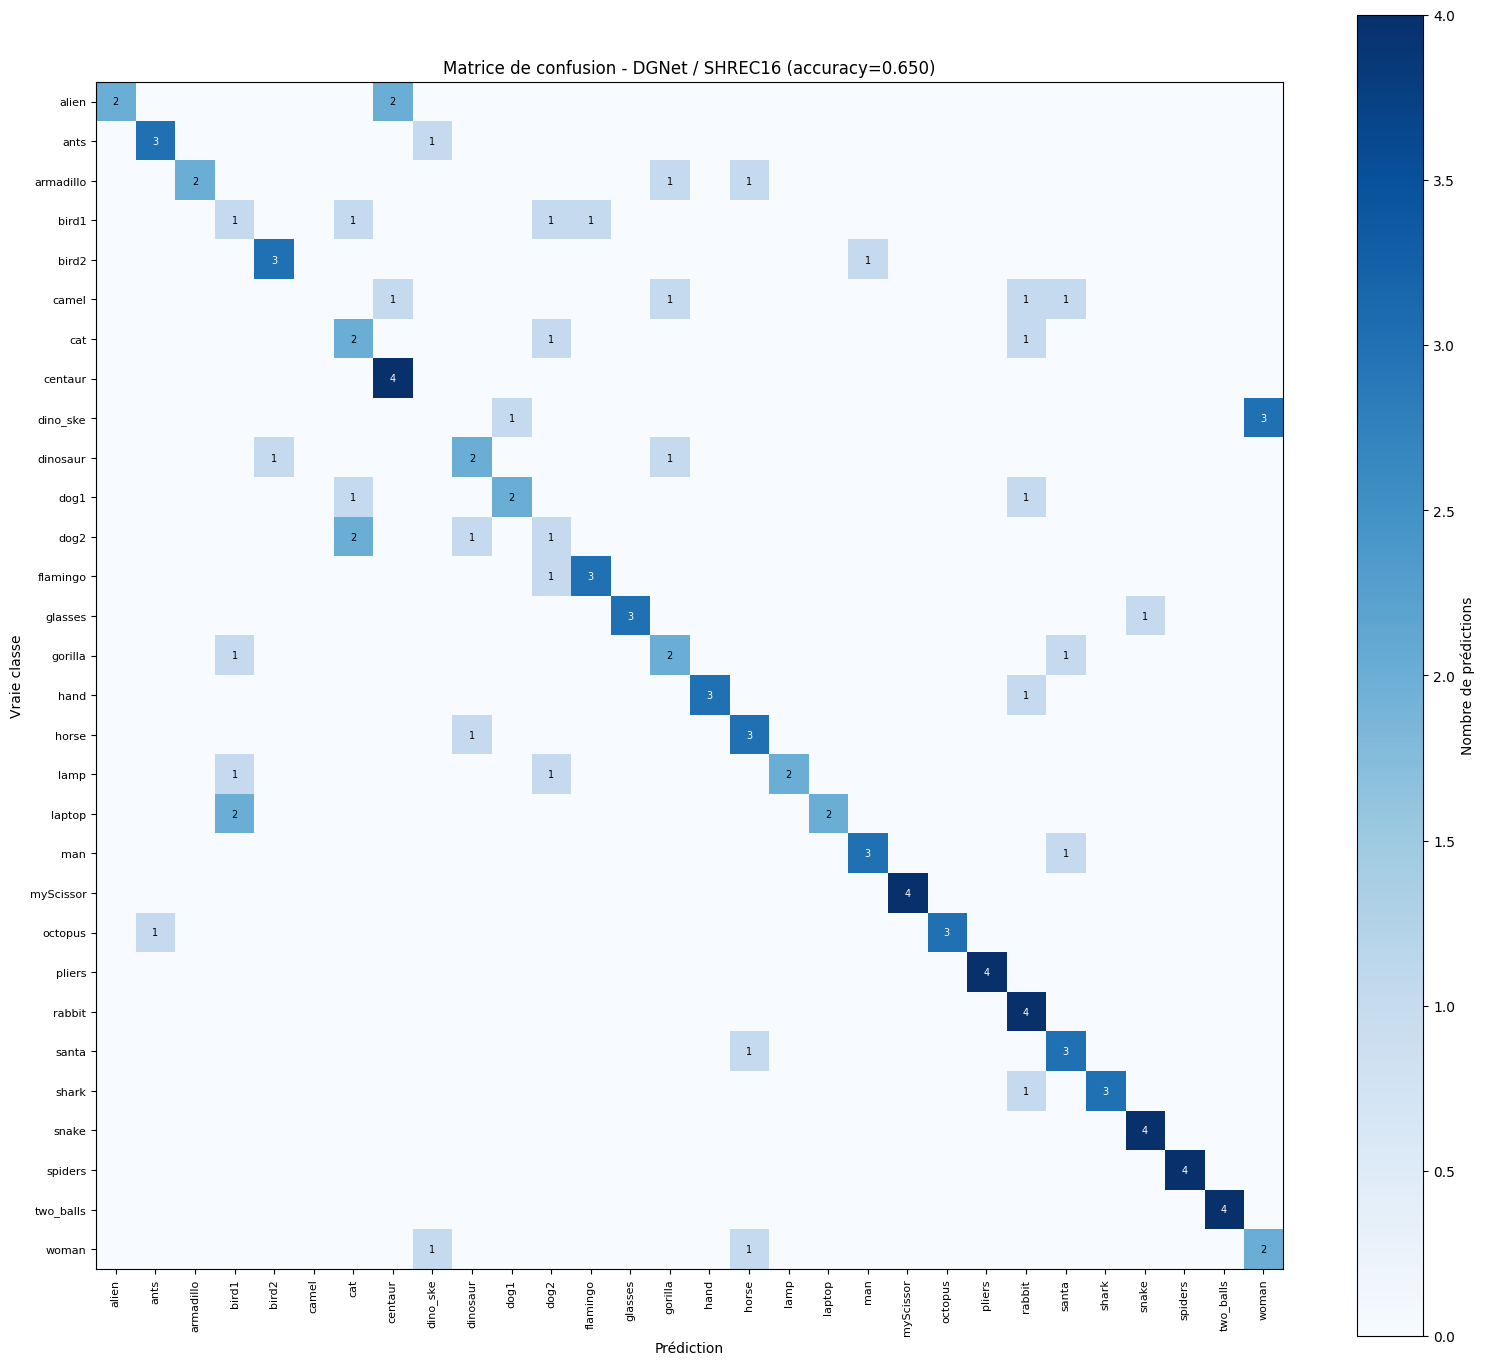

Matrice sauvegardée : /kaggle/working/shrec16_training_output/confusion_matrix_shrec16.png

=== Métriques de classification ===
Accuracy              : 0.6500
Precision (macro)     : 0.6839
Recall (macro)        : 0.6500
F1-score (macro)      : 0.6444
Precision (weighted)  : 0.6839
Recall (weighted)     : 0.6500
F1-score (weighted)   : 0.6444

              precision    recall  f1-score   support

       alien       1.00      0.50      0.67         4
        ants       0.75      0.75      0.75         4
   armadillo       1.00      0.50      0.67         4
       bird1       0.20      0.25      0.22         4
       bird2       0.75      0.75      0.75         4
       camel       0.00      0.00      0.00         4
         cat       0.33      0.50      0.40         4
     centaur       0.57      1.00      0.73         4
    dino_ske       0.00      0.00      0.00         4
    dinosaur       0.50      0.50      0.50         4
        dog1       0.67      0.50      0.57         4
     

In [25]:
import json
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    confusion_matrix, accuracy_score, classification_report,
    precision_recall_fscore_support,
)

CLASS_NAMES = [
    "alien", "ants", "armadillo", "bird1", "bird2", "camel", "cat", "centaur",
    "dino_ske", "dinosaur", "dog1", "dog2", "flamingo", "glasses", "gorilla",
    "hand", "horse", "lamp", "laptop", "man", "myScissor", "octopus", "pliers",
    "rabbit", "santa", "shark", "snake", "spiders", "two_balls", "woman",
]

predictions_data = np.load(SHREC16_TRAINING_OUTPUT_DIR / "final_predictions.npz")
y_pred = predictions_data["predictions"]
y_true = predictions_data["labels"]

# --- Métriques globales (calculées avant le titre, pour l'afficher dans la matrice) ---
accuracy = accuracy_score(y_true, y_pred)
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0
)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0
)

# --- Matrice de confusion ---
cm = confusion_matrix(y_true, y_pred, labels=range(len(CLASS_NAMES)))

fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=90, ha="center", fontsize=8)
ax.set_yticklabels(CLASS_NAMES, fontsize=8)
ax.set_xlabel("Prédiction")
ax.set_ylabel("Vraie classe")
ax.set_title(f"Matrice de confusion - DGNet / SHREC16 (accuracy={accuracy:.3f})")

for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        if cm[i, j] > 0:
            text_color = "white" if cm[i, j] > cm.max() / 2 else "black"
            ax.text(j, i, f"{cm[i, j]}", ha="center", va="center", color=text_color, fontsize=7)

fig.colorbar(im, ax=ax, label="Nombre de prédictions")
plt.tight_layout()
cm_path = SHREC16_TRAINING_OUTPUT_DIR / "confusion_matrix_shrec16.png"
plt.savefig(cm_path, dpi=150)
plt.show()
print("Matrice sauvegardée :", cm_path)

# --- Métriques globales (macro + weighted) ---
print("\n=== Métriques de classification ===")
print(f"Accuracy              : {accuracy:.4f}")
print(f"Precision (macro)     : {precision_macro:.4f}")
print(f"Recall (macro)        : {recall_macro:.4f}")
print(f"F1-score (macro)      : {f1_macro:.4f}")
print(f"Precision (weighted)  : {precision_weighted:.4f}")
print(f"Recall (weighted)     : {recall_weighted:.4f}")
print(f"F1-score (weighted)   : {f1_weighted:.4f}")

# --- Rapport détaillé par classe ---
print("\n" + classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

# --- Les confusions les plus fréquentes (hors diagonale) ---
print("\n=== Top 15 confusions les plus fréquentes ===")
confusions = []
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        if i != j and cm[i, j] > 0:
            confusions.append((cm[i, j], CLASS_NAMES[i], CLASS_NAMES[j]))
confusions.sort(reverse=True)
for count, true_class, pred_class in confusions[:15]:
    print(f"  {true_class:<12} confondu avec {pred_class:<12} : {count} fois")


In [26]:
shrec16_computational_metrics_script_path = WORKING_ROOT / "run_shrec16_computational_metrics.py"

shrec16_computational_metrics_script_source = '''
import sys
import time
import json
import subprocess
from pathlib import Path

import jittor as jt
import numpy as np

PROJECT_ROOT = Path(sys.argv[1])
PREPROCESSED_ROOT = Path(sys.argv[2])
OUTPUT_DIR = Path(sys.argv[3])

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "models" / "dgnet"))
from adapters.dgnet.mesh_dataset import ModelNet10Classification
from adapters.dgnet.modelnet10_classifier import DGNetClassifier

from jmesh.models.dgnet import SpatialConv, sample_spatialface, dilated_face_adjacencies, sample_adj


def patched_spatialconv_execute(self, mesh):
    feats = mesh.feats
    Fs = mesh.Fs
    f1 = self.conv_f(feats)
    if self.kernel_size == 3:
        f2 = self.conv_mf(feats)
        adj = mesh.face_adjacency
        adj = dilated_face_adjacencies(adj, self.dilation)
        f2 = sample_adj(f2, adj, Fs, self.merge_op)
    else:
        f2 = 0.
    if self.with_spatial:
        sample_size = 5
        adj_feats = sample_spatialface(mesh, dilation=self.spatial_dilation, sample_size=sample_size)
        weight = self.conv_sf.weight
        N_, Cin_, F_, sd_ = adj_feats.shape
        out_channels_ = weight.shape[0]
        w_flat = weight.reshape(out_channels_, Cin_ * sd_)
        x_flat = adj_feats.permute(0, 2, 1, 3).reshape(N_, F_, Cin_ * sd_)
        f3 = jt.matmul(x_flat, w_flat.transpose(1, 0))
        f3 = f3.permute(0, 2, 1)
    else:
        f3 = 0.
    ff = [f1]
    if isinstance(f2, jt.Var):
        ff.append(f2)
    if isinstance(f3, jt.Var):
        ff.append(f3)
    feats = sum(ff)
    attn_c = self.se(feats.mean(dim=-1))
    feats = attn_c[:, :, None] * feats
    return mesh.updated(feats=feats)


SpatialConv.execute = patched_spatialconv_execute

CLASS_NAMES = [
    "alien", "ants", "armadillo", "bird1", "bird2", "camel", "cat", "centaur",
    "dino_ske", "dinosaur", "dog1", "dog2", "flamingo", "glasses", "gorilla",
    "hand", "horse", "lamp", "laptop", "man", "myScissor", "octopus", "pliers",
    "rabbit", "santa", "shark", "snake", "spiders", "two_balls", "woman",
]

WARMUP_ITERATIONS = 10

jt.flags.use_cuda = 1 if jt.has_cuda else 0

model = DGNetClassifier(in_channels=13, num_classes=len(CLASS_NAMES))
model.load(str(OUTPUT_DIR / "checkpoints" / "best_model.pkl"))
model.eval()

num_params = sum(p.numel() for p in model.parameters())

test_dataset = ModelNet10Classification(
    dataroot=PREPROCESSED_ROOT, class_names=CLASS_NAMES, split="test",
    batch_size=1, shuffle=False, num_workers=0,
)

all_inference_times = []
with jt.no_grad():
    for mesh_tensor, labels in test_dataset:
        jt.sync_all(True)
        started_at = time.perf_counter()
        logits = model(mesh_tensor)
        jt.sync_all(True)
        all_inference_times.append(time.perf_counter() - started_at)

all_inference_times = np.array(all_inference_times)
steady_times = all_inference_times[WARMUP_ITERATIONS:]

avg_inference_time_steady = float(steady_times.mean())
std_inference_time_steady = float(steady_times.std())

try:
    nvidia_smi_result = subprocess.run(
        ["nvidia-smi", "--query-gpu=memory.used,memory.total", "--format=csv,noheader,nounits"],
        capture_output=True, text=True, check=True,
    )
    used_mb, total_mb = nvidia_smi_result.stdout.strip().split(",")
    gpu_memory_used_mb = float(used_mb.strip())
    gpu_memory_total_mb = float(total_mb.strip())
except Exception:
    gpu_memory_used_mb = None
    gpu_memory_total_mb = None

try:
    gpu_name_result = subprocess.run(
        ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
        capture_output=True, text=True, check=True,
    )
    gpu_name = gpu_name_result.stdout.strip()
except Exception:
    gpu_name = "inconnu"

computational_metrics = {
    "num_parameters": int(num_params),
    "avg_inference_time_ms_steady_state": avg_inference_time_steady * 1000,
    "std_inference_time_ms_steady_state": std_inference_time_steady * 1000,
    "gpu_memory_used_mb": gpu_memory_used_mb,
    "gpu_memory_total_mb": gpu_memory_total_mb,
    "gpu_name": gpu_name,
    "test_set_size": len(test_dataset.files),
}

with open(OUTPUT_DIR / "computational_metrics.json", "w", encoding="utf-8") as f:
    json.dump(computational_metrics, f, indent=2)

print("Nombre de parametres :", num_params)
print(f"Temps d'inference (regime stable): {avg_inference_time_steady*1000:.2f} ms")
print("GPU :", gpu_name, "-", gpu_memory_used_mb, "/", gpu_memory_total_mb, "Mo")
print("\\n✅ Metriques calculatoires sauvegardees.")
'''

shrec16_computational_metrics_script_path.write_text(shrec16_computational_metrics_script_source, encoding="utf-8")
print("Script écrit :", shrec16_computational_metrics_script_path)

Script écrit : /kaggle/working/run_shrec16_computational_metrics.py


In [27]:
process = subprocess.Popen(
    [str(VENV_PYTHON), "-S", str(shrec16_computational_metrics_script_path), str(PROJECT_ROOT), str(SHREC16_OUTPUT_ROOT), str(SHREC16_TRAINING_OUTPUT_DIR)],
    cwd=WORKING_ROOT,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
    env=VENV_ENV,
)
for line in process.stdout:
    print(line, end="")
process.wait()
print("\nCode retour :", process.returncode)

[i 0915 11:55:54.883148 36 compiler.py:955] Jittor(1.3.11.0) src: /kaggle/working/dgnet-jittor-env/lib/python3.10/site-packages/jittor
[i 0915 11:55:54.886772 36 compiler.py:956] g++ at /usr/bin/g++(11.4.0)
[i 0915 11:55:54.886877 36 compiler.py:957] cache_path: /root/.cache/jittor/jt1.3.11/g++11.4.0/py3.10.12/Linux-6.12.90+xce/IntelRXeonRCPUx5a/9ee7/default
[i 0915 11:55:54.890772 36 __init__.py:412] Found nvcc(12.8.93) at /usr/local/cuda/bin/nvcc.
[i 0915 11:55:54.894209 36 __init__.py:412] Found addr2line(2.38) at /usr/bin/addr2line.
[i 0915 11:55:55.334189 36 compiler.py:1012] cuda key:cu12.8.93_sm_75
[i 0915 11:55:55.902624 36 __init__.py:227] Total mem: 31.35GB, using 10 procs for compiling.
[i 0915 11:55:56.062029 36 jit_compiler.cc:28] Load cc_path: /usr/bin/g++
[i 0915 11:55:56.493626 36 init.cc:63] Found cuda archs: [75,]
[i 0915 11:55:56.506137 36 __init__.py:412] Found mpicc(4.1.2) at /usr/bin/mpicc.
[w 0915 11:55:56.606163 36 compile_extern.py:203] CUDA related path found 

In [28]:
from sklearn.metrics import precision_recall_fscore_support

accuracy = accuracy_score(y_true, y_pred)
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0
)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0
)

classification_metrics = {
    "accuracy": float(accuracy),
    "precision_macro": float(precision_macro),
    "recall_macro": float(recall_macro),
    "f1_macro": float(f1_macro),
    "precision_weighted": float(precision_weighted),
    "recall_weighted": float(recall_weighted),
    "f1_weighted": float(f1_weighted),
}
with open(SHREC16_TRAINING_OUTPUT_DIR / "classification_metrics.json", "w", encoding="utf-8") as f:
    json.dump(classification_metrics, f, indent=2)

with open(SHREC16_TRAINING_OUTPUT_DIR / "training_info.json") as f:
    training_info = json.load(f)
with open(SHREC16_TRAINING_OUTPUT_DIR / "computational_metrics.json") as f:
    computational_metrics = json.load(f)

zero_score_classes = [
    CLASS_NAMES[i] for i in range(len(CLASS_NAMES))
    if precision_recall_fscore_support(
        y_true == i, y_pred == i, average="binary", zero_division=0
    )[2] == 0
]

confusions = []
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        if i != j and cm[i, j] > 0:
            confusions.append((cm[i, j], CLASS_NAMES[i], CLASS_NAMES[j]))
confusions.sort(reverse=True)
top_confusions_md = "\n".join(
    f"- `{true_class}` confondu avec `{pred_class}` : {count} fois"
    for count, true_class, pred_class in confusions[:10]
) or "- Aucune confusion notable."

report_content = f"""# Rapport d'expérience — DGNet sur SHREC16 Original

## 1. Architecture et implémentation

| Champ | Valeur |
|---|---|
| Architecture | DGNet |
| Dépôt officiel | https://github.com/li-xl/DGNet |
| Dataset | SHREC16 Original (format .obj, dépôt MeshCNN) |
| Nombre de classes | 30 |
| Modifications | Identiques à celles documentées pour ModelNet10 (§5.1) : tête de
classification, radius=[None,0.2,0.4,0.8], SpatialConv.execute patché (matmul),
normalisation des sommets, environnement Python 3.10 |

## 2. Particularité du prétraitement

Contrairement à ModelNet10, les maillages SHREC16 sont déjà uniformément simplifiés
à exactement 500 faces par le dataset source — **aucune étape de simplification
Open3D n'a été nécessaire**. La pyramide DGNet à 6 niveaux a été construite
directement, avec un pilote réussi à 30/30 classes puis un prétraitement complet
des 600 maillages (480 train / 120 test).

## 3. Configuration d'entraînement

| Paramètre | Valeur |
|---|---|
| Nombre d'epochs | {training_info['num_epochs']} |
| Batch size | {training_info['batch_size']} |
| Optimiseur | {training_info['optimizer']} |
| Learning rate initial | {training_info['learning_rate']} |
| Scheduler | {training_info['lr_scheduler']} |
| Weight decay | {training_info['weight_decay']} |
| Loss function | {training_info['loss_function']} |
| Hardware | {computational_metrics['gpu_name']} |
| Seed aléatoire | {training_info['random_seed']} |
| Taille train / test | {training_info['train_size']} / {training_info['test_size']} |
| Durée totale d'entraînement | {training_info['total_training_time_seconds']/60:.1f} min |
| Meilleure epoch | {training_info['best_epoch']} |

## 4. Résultats

| Métrique | Macro | Weighted |
|---|---|---|
| Precision | {classification_metrics['precision_macro']:.4f} | {classification_metrics['precision_weighted']:.4f} |
| Recall | {classification_metrics['recall_macro']:.4f} | {classification_metrics['recall_weighted']:.4f} |
| F1-score | {classification_metrics['f1_macro']:.4f} | {classification_metrics['f1_weighted']:.4f} |

**Accuracy globale : {classification_metrics['accuracy']:.4f}**

| Ressources | Valeur |
|---|---|
| Nombre de paramètres | {computational_metrics['num_parameters']:,} |
| Temps d'inférence (régime stable) | {computational_metrics['avg_inference_time_ms_steady_state']:.2f} ms |
| Mémoire GPU utilisée | {computational_metrics['gpu_memory_used_mb']:.0f} / {computational_metrics['gpu_memory_total_mb']:.0f} Mo |

## 5. Analyse

SHREC16 ne compte que 16 maillages d'entraînement et 4 de test par classe — un
volume nettement plus faible que ModelNet10, ce qui rend la tâche plus sensible
au choix des hyperparamètres et à la variance d'échantillonnage.

**{len(zero_score_classes)} classe(s) sur 30 ont un F1-score de 0** (jamais prédite(s)
correctement){": " + ", ".join(zero_score_classes) if zero_score_classes else ""}.

Top confusions observées (hors diagonale) :

{top_confusions_md}

Ce résultat constitue une baseline pour la comparaison avec la version
augmentée du dataset (cahier des charges §2, "Analyzing the effect of augmentation"),
l'augmentation de données étant la technique attendue pour compenser le faible
nombre d'exemples par classe.

## 6. Visualisations

- Matrice de confusion : `confusion_matrix_shrec16.png`
- Rapport de classification détaillé par classe disponible dans les logs d'exécution

## 7. Reproductibilité

- Seed aléatoire : {training_info['random_seed']}
- Checkpoints : `checkpoints/best_model.pkl`, `checkpoints/final_model.pkl`
- Historique complet : `training_history.csv`
- Prédictions finales (test) : `final_predictions.npz`
"""

report_path = SHREC16_TRAINING_OUTPUT_DIR / "RAPPORT_DGNet_SHREC16.md"
report_path.write_text(report_content, encoding="utf-8")
print("Rapport écrit :", report_path)


TypeError: unsupported format string passed to NoneType.__format__